In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

In [71]:

# 1. Carregamento (Mantendo suas bases macro)
df_bacen = pd.read_csv('juros_cambio.csv')
df_agro_inflacao = pd.read_csv('agro_inflacao_anual.csv')
df_milho_raw = pd.read_excel('dados_milho.xlsx')

# 2. Tratamento e Melt
df_milho_melt = df_milho_raw.melt(
    id_vars=['Commodity', 'Country', 'Attribute', 'Unit Description'], 
    var_name='Ano_Safra', 
    value_name='Valor'
)

# Limpeza de strings e conversão numérica (Prevenindo o erro de '5.40 ')
df_milho_melt['Ano'] = pd.to_numeric(df_milho_melt['Ano_Safra'].astype(str).str[:4], errors='coerce')
df_milho_melt['Valor'] = pd.to_numeric(df_milho_melt['Valor'].astype(str).str.strip().str.replace(',', '.'), errors='coerce')
df_milho_melt.dropna(subset=['Ano', 'Valor'], inplace=True)

# Criamos o nome da coluna com o Atributo + Unidade (Ex: "Production (1000 MT)")
df_milho_melt['Variavel'] = df_milho_melt['Attribute'] + ' (' + df_milho_melt['Unit Description'].astype(str) + ')'

# 3. O PIVOT CORRETO
# Colocamos 'Country' no INDEX. Assim ele vira uma coluna de dados, não de título.
df_milho_pivot = df_milho_melt.pivot_table(
    index=['Ano', 'Country'], 
    columns='Variavel', 
    values='Valor'
).reset_index()

# 4. MERGE COM MACROECONOMIA
# Como o Bacen/Inflação são dados do Brasil, ao dar o merge, 
# os valores de juros/câmbio vão se repetir para a linha "World" do mesmo ano.
# Isso é o que você chamou de "eternos repetidos", e está correto para análise correlacional.
df_final = pd.merge(df_milho_pivot, df_bacen, on='Ano', how='inner')
df_final = pd.merge(df_final, df_agro_inflacao, on='Ano', how='inner')

# 5. Visualização (Para você conferir as colunas)
pd.set_option('display.max_columns', None)
display(df_final.head(40))

# Agora você consegue filtrar facilmente:
# df_brasil = df_final[df_final['Country'] == 'Brazil']
# df_mundo = df_final[df_final['Country'] == 'World']

print(f"Países na base: {df_final['Country'].unique()}")

,Ano,Country,Area Harvested ((1000 HA)),Domestic Consumption ((1000 MT)),Ending Stocks ((1000 MT)),Exports ((1000 MT)),Imports ((1000 MT)),Production ((1000 MT)),Yield ((MT/HA)),Taxa_Cambio,Taxa_Selic,IC_Br_Agro,IPCA_Anual_Pct
0,2000,Brazil,12.972,34.500,2.686,6.261,244.000,41.536,3.20,1.8295,17.60,59.93,5.97
1,2000,World,136.996,609.231,175.136,76.722,75.144,591.538,4.32,1.8295,17.60,59.93,5.97
2,2001,Brazil,11.827,35.000,1.500,2.054,367.000,35.501,3.00,2.3522,17.46,71.84,7.67
3,2001,World,136.883,622.678,151.409,74.579,71.878,601.652,4.40,2.3522,17.46,71.84,7.67
4,2002,Brazil,12.956,35.800,6.258,4.625,683.000,44.500,3.44,2.9309,19.22,85.90,12.53
5,2002,World,137.516,628.071,126.942,76.746,76.240,604.110,4.39,2.9309,19.22,85.90,12.53
6,2003,Brazil,12.440,36.300,7.878,4.441,361.000,42.000,3.38,3.0715,23.52,103.49,9.30
7,2003,World,141.340,649.457,104.701,77.135,76.819,627.532,4.44,3.0715,23.52,103.49,9.30
8,2004,Brazil,11.561,38.500,4.193,0.681,496.000,35.000,3.03,2.9257,16.38,106.92,7.60
9,2004,World,145.151,689.240,131.156,77.659,76.450,716.904,4.94,2.9257,16.38,106.92,7.60


Países na base: <StringArray>
['Brazil', 'World']
Length: 2, dtype: str


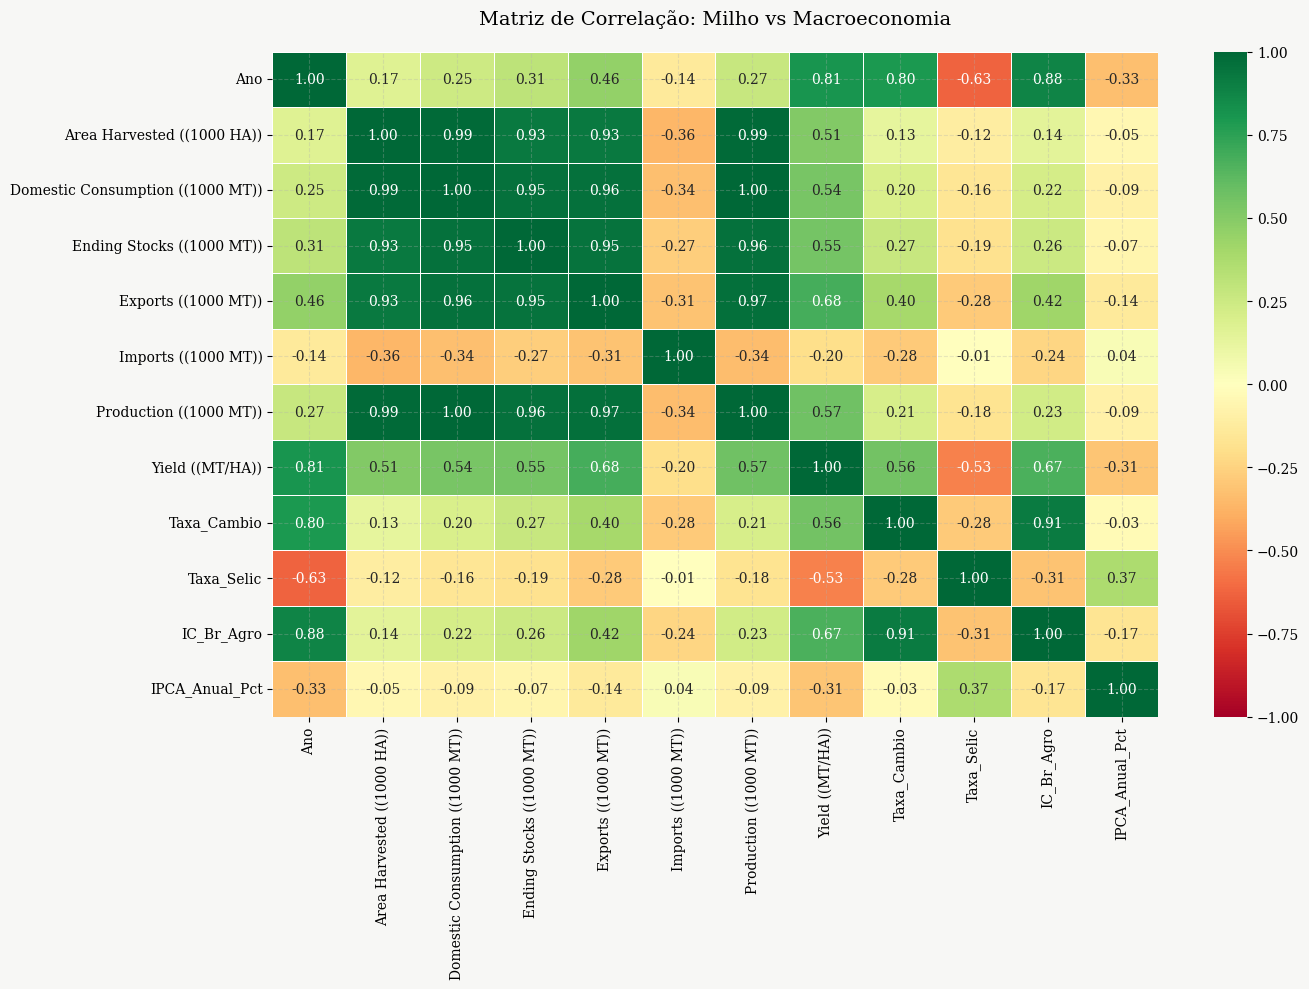

In [72]:
# 4. Matriz de Correlação (Heatmap)
# Pega apenas colunas numéricas para a matemática não quebrar
cols_analise = df_final.select_dtypes(include=[np.number]).columns
df_analise = df_final[cols_analise]

plt.figure(figsize=(14, 10))
correlation_matrix = df_analise.corr()

# Estética de consultoria para o Heatmap
sns.heatmap(correlation_matrix, 
            annot=True,          
            cmap='RdYlGn',       
            fmt=".2f",           
            vmin=-1, vmax=1,     
            linewidths=0.5)

plt.title('Matriz de Correlação: Milho vs Macroeconomia', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [73]:
# ============================================================
# SETUP DE ANALISE
# ============================================================
 
brazil = df_final[df_final['Country'] == 'Brazil'].set_index('Ano').sort_index()
world  = df_final[df_final['Country'] == 'World'].set_index('Ano').sort_index()
anos   = brazil.index.astype(int)
 
# Detecta automaticamente os nomes das colunas
# (evita erro se houver espaco extra ou diferenca de capitalizacao)
def achar_coluna(df, palavra_chave):
    matches = [c for c in df.columns if palavra_chave.lower() in c.lower()]
    if not matches:
        raise ValueError(f"Coluna com '{palavra_chave}' nao encontrada. Colunas: {list(df.columns)}")
    return matches[0]
 
COL_PROD   = achar_coluna(brazil, 'Production')
COL_EXP    = achar_coluna(brazil, 'Export')
COL_AREA   = achar_coluna(brazil, 'Area Harvested')
COL_YIELD  = achar_coluna(brazil, 'Yield')
COL_CAMBIO = achar_coluna(brazil, 'Cambio')  # ajuste se o nome for diferente
 
print(f"Colunas identificadas:")
print(f"  Producao   -> {COL_PROD}")
print(f"  Exportacao -> {COL_EXP}")
print(f"  Area       -> {COL_AREA}")
print(f"  Yield      -> {COL_YIELD}")
print(f"  Cambio     -> {COL_CAMBIO}\n")

Colunas identificadas:
  Producao   -> Production ((1000 MT))
  Exportacao -> Exports ((1000 MT))
  Area       -> Area Harvested ((1000 HA))
  Yield      -> Yield ((MT/HA))
  Cambio     -> Taxa_Cambio



In [ ]:
# ============================================================
# CALCULO DOS INDICADORES
# ============================================================
 
ms_producao   = (brazil[COL_PROD]  / world[COL_PROD]  * 100).round(2)
ms_exportacao = (brazil[COL_EXP]   / world[COL_EXP]   * 100).round(2)
prod_relativa = (brazil[COL_YIELD] / world[COL_YIELD]).round(3)
 
# Indice base 100 para decomposicao
area_idx  = brazil[COL_AREA]  / brazil[COL_AREA].iloc[0]  * 100
yield_idx = brazil[COL_YIELD] / brazil[COL_YIELD].iloc[0] * 100
prod_idx  = brazil[COL_PROD]  / brazil[COL_PROD].iloc[0]  * 100
 
# CAGR
def cagr(serie, inicio, fim):
    return ((serie.loc[fim] / serie.loc[inicio]) ** (1 / (fim - inicio)) - 1) * 100
 
inicio, fim = int(anos.min()), int(anos.max())
 
cagr_prod_br  = cagr(brazil[COL_PROD], inicio, fim)
cagr_prod_wld = cagr(world[COL_PROD],  inicio, fim)
cagr_exp_br   = cagr(brazil[COL_EXP],  inicio, fim)
cagr_exp_wld  = cagr(world[COL_EXP],   inicio, fim)
 
# Correlacao cambio x market share exportacao
df_corr = pd.DataFrame({
    'ms_exportacao': ms_exportacao,
    'cambio':        brazil[COL_CAMBIO]
}).dropna()
correlacao_cambio = df_corr.corr().loc['ms_exportacao', 'cambio']
 
# ============================================================
# RESULTADOS NO TERMINAL
# ============================================================
sep = "=" * 60
print(sep)
print("  RESULTADOS - MILHO BRASILEIRO")
print(sep)
 
print(f"\nMarket Share PRODUCAO  ({inicio} -> {fim})")
print(f"  {inicio}: {ms_producao.loc[inicio]:.1f}%  ->  {fim}: {ms_producao.loc[fim]:.1f}%")
print(f"  Variacao: +{ms_producao.loc[fim] - ms_producao.loc[inicio]:.1f} p.p.")
print(f"  CAGR Brasil: {cagr_prod_br:.1f}% a.a.  |  Mundo: {cagr_prod_wld:.1f}% a.a.")
 
print(f"\nMarket Share EXPORTACAO ({inicio} -> {fim})")
print(f"  {inicio}: {ms_exportacao.loc[inicio]:.1f}%  ->  {fim}: {ms_exportacao.loc[fim]:.1f}%")
print(f"  Variacao: +{ms_exportacao.loc[fim] - ms_exportacao.loc[inicio]:.1f} p.p.")
print(f"  CAGR Brasil: {cagr_exp_br:.1f}% a.a.  |  Mundo: {cagr_exp_wld:.1f}% a.a.")
 
print(f"\nProdutividade Relativa (Brasil / Mundo)")
print(f"  {inicio}: {prod_relativa.loc[inicio]:.2f}x  ->  {fim}: {prod_relativa.loc[fim]:.2f}x")
print(f"  (>1 = Brasil mais produtivo que a media global)")
 
print(f"\nCorrelacao Cambio x Market Share Exportacao: r = {correlacao_cambio:.3f}")
if abs(correlacao_cambio) > 0.4:
    print("  Correlacao relevante - real desvalorizado favorece exportacoes")
else:
    print("  Correlacao fraca - outros fatores dominam")
 
print(f"\n{sep}")

KeyError: "['Production (1000 MT)', 'Exports (1000 MT)'] not in index"

In [75]:
# ============================================================
# PALETA VISUAL
# ============================================================
COR_BRASIL   = "#1A7A3C"
COR_EXPORT   = "#0D4F26"
COR_DESTAQUE = "#F4A800"
COR_FUNDO    = "#F7F7F5"
COR_TEXTO    = "#1A1A1A"
 
plt.rcParams.update({
    "figure.facecolor": COR_FUNDO,
    "axes.facecolor":   COR_FUNDO,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.family":       "serif",
    "axes.titlesize":    12,
    "axes.labelsize":    10,
})

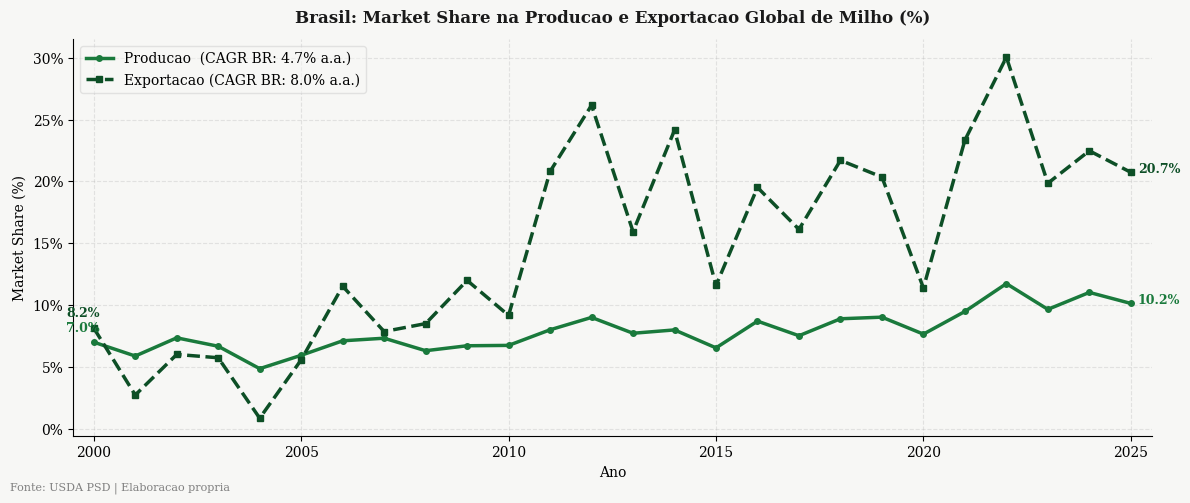

Grafico 1 salvo


In [76]:
#============================================================
# GRAFICO 1 - Market Share Producao + Exportacao
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
 
ax.plot(anos, ms_producao,   color=COR_BRASIL, lw=2.5, marker='o', ms=4,
        label=f"Producao  (CAGR BR: {cagr_prod_br:.1f}% a.a.)")
ax.plot(anos, ms_exportacao, color=COR_EXPORT, lw=2.5, marker='s', ms=4, ls='--',
        label=f"Exportacao (CAGR BR: {cagr_exp_br:.1f}% a.a.)")
 
for serie, cor in [(ms_producao, COR_BRASIL), (ms_exportacao, COR_EXPORT)]:
    ax.annotate(f"{serie.iloc[0]:.1f}%",  xy=(anos[0],  serie.iloc[0]),
                xytext=(-20, 8), textcoords='offset points', fontsize=9, color=cor, fontweight='bold')
    ax.annotate(f"{serie.iloc[-1]:.1f}%", xy=(anos[-1], serie.iloc[-1]),
                xytext=(5, 0),   textcoords='offset points', fontsize=9, color=cor, fontweight='bold')
 
ax.set_title("Brasil: Market Share na Producao e Exportacao Global de Milho (%)",
             fontweight='bold', color=COR_TEXTO, pad=12)
ax.set_xlabel("Ano")
ax.set_ylabel("Market Share (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax.legend(fontsize=10, framealpha=0.5)
ax.set_xlim(anos.min() - 0.5, anos.max() + 0.5)
fig.text(0.01, 0.01, "Fonte: USDA PSD | Elaboracao propria", fontsize=8, color='gray')
 
plt.tight_layout()
plt.savefig("grafico1_market_share.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafico 1 salvo")

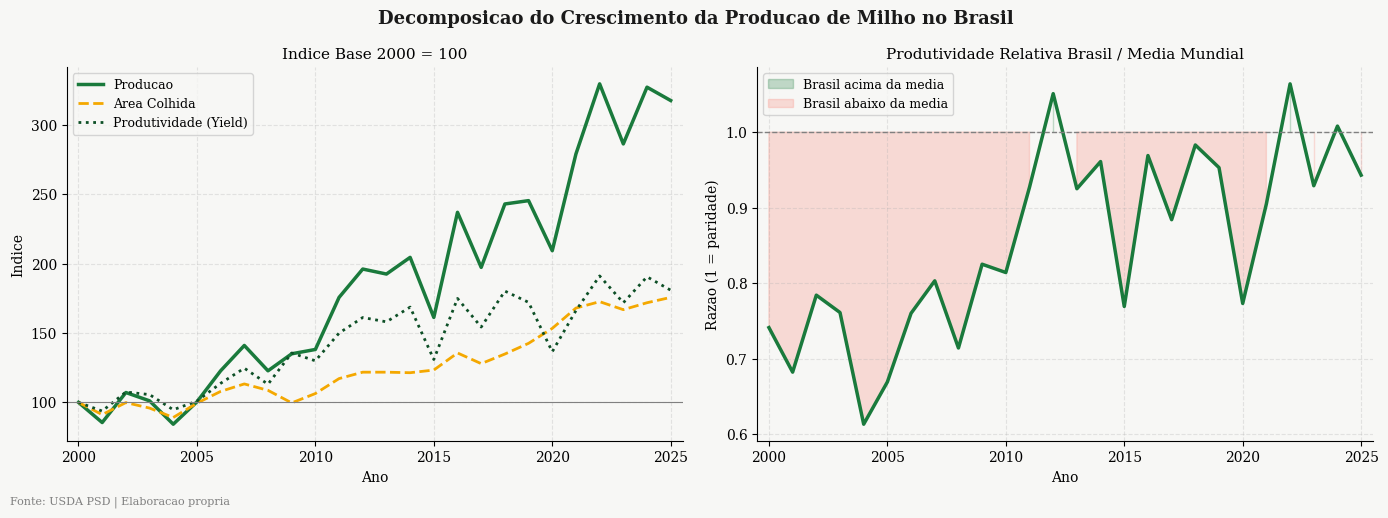

Grafico 2 salvo


In [77]:
# ============================================================
# GRAFICO 2 - Decomposicao Area vs Yield + Produtividade Relativa
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Decomposicao do Crescimento da Producao de Milho no Brasil",
             fontweight='bold', color=COR_TEXTO, fontsize=13)
 
ax = axes[0]
ax.plot(anos, prod_idx,  color=COR_BRASIL,   lw=2.5, label='Producao')
ax.plot(anos, area_idx,  color=COR_DESTAQUE, lw=2,   ls='--', label='Area Colhida')
ax.plot(anos, yield_idx, color=COR_EXPORT,   lw=2,   ls=':',  label='Produtividade (Yield)')
ax.axhline(100, color='gray', lw=0.8)
ax.set_title(f"Indice Base {inicio} = 100", fontsize=11)
ax.set_ylabel("Indice")
ax.set_xlabel("Ano")
ax.legend(fontsize=9)
ax.set_xlim(anos.min() - 0.5, anos.max() + 0.5)
 
ax2 = axes[1]
ax2.fill_between(anos, 1, prod_relativa,
                 where=(prod_relativa >= 1), alpha=0.25, color=COR_BRASIL, label='Brasil acima da media')
ax2.fill_between(anos, 1, prod_relativa,
                 where=(prod_relativa < 1),  alpha=0.25, color='salmon',   label='Brasil abaixo da media')
ax2.plot(anos, prod_relativa, color=COR_BRASIL, lw=2.5)
ax2.axhline(1, color='gray', lw=1, ls='--')
ax2.set_title("Produtividade Relativa Brasil / Media Mundial", fontsize=11)
ax2.set_ylabel("Razao (1 = paridade)")
ax2.set_xlabel("Ano")
ax2.legend(fontsize=9)
ax2.set_xlim(anos.min() - 0.5, anos.max() + 0.5)
 
fig.text(0.01, -0.01, "Fonte: USDA PSD | Elaboracao propria", fontsize=8, color='gray')
plt.tight_layout()
plt.savefig("grafico2_decomposicao.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafico 2 salvo")

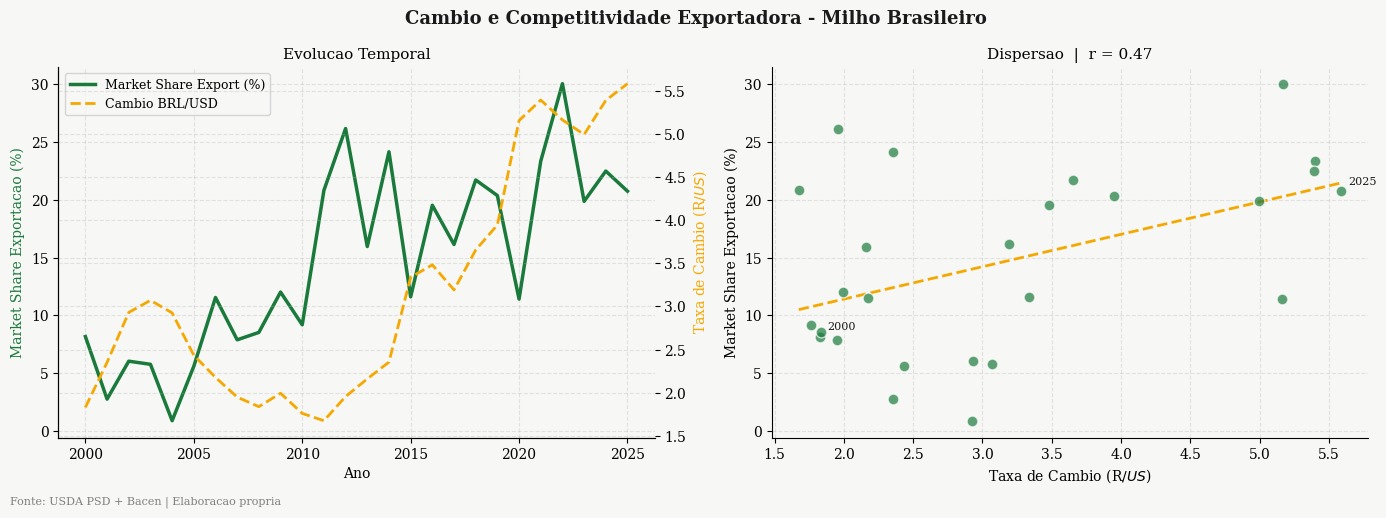

Grafico 3 salvo


In [78]:
# ============================================================
# GRAFICO 3 - Cambio x Market Share Exportacao
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cambio e Competitividade Exportadora - Milho Brasileiro",
             fontweight='bold', color=COR_TEXTO, fontsize=13)
 
ax1  = axes[0]
ax1b = ax1.twinx()
ax1.plot(df_corr.index,  df_corr['ms_exportacao'], color=COR_BRASIL,   lw=2.5, label='Market Share Export (%)')
ax1b.plot(df_corr.index, df_corr['cambio'],        color=COR_DESTAQUE, lw=2,   ls='--', label='Cambio BRL/USD')
ax1.set_ylabel("Market Share Exportacao (%)", color=COR_BRASIL)
ax1b.set_ylabel("Taxa de Cambio (R$/US$)",    color=COR_DESTAQUE)
ax1.set_title("Evolucao Temporal", fontsize=11)
ax1.set_xlabel("Ano")
lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, fontsize=9)
 
ax2 = axes[1]
ax2.scatter(df_corr['cambio'], df_corr['ms_exportacao'],
            color=COR_BRASIL, alpha=0.7, edgecolors='white', s=60, zorder=3)
 
z = np.polyfit(df_corr['cambio'], df_corr['ms_exportacao'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_corr['cambio'].min(), df_corr['cambio'].max(), 100)
ax2.plot(x_line, p(x_line), color=COR_DESTAQUE, lw=2, ls='--')
 
for ano in [inicio, fim]:
    if ano in df_corr.index:
        ax2.annotate(str(ano),
                     xy=(df_corr.loc[ano, 'cambio'], df_corr.loc[ano, 'ms_exportacao']),
                     xytext=(5, 5), textcoords='offset points', fontsize=8, color=COR_TEXTO)
 
ax2.set_title(f"Dispersao  |  r = {correlacao_cambio:.2f}", fontsize=11)
ax2.set_xlabel("Taxa de Cambio (R$/US$)")
ax2.set_ylabel("Market Share Exportacao (%)")
 
fig.text(0.01, -0.01, "Fonte: USDA PSD + Bacen | Elaboracao propria", fontsize=8, color='gray')
plt.tight_layout()
plt.savefig("grafico3_cambio_export.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafico 3 salvo")

In [85]:
# Filtros Iniciais
df_br = df_final[df_final['Country'] == 'Brazil'].copy()
df_wd = df_final[df_final['Country'] == 'World'].copy()

# PADRONIZAÇÃO DE NOMES (O segredo para não ter mais KeyError)
# Vamos renomear as colunas complexas para nomes simples
mapeamento_nomes = {
    'Production ((1000 MT))': 'Producao',
    'Exports ((1000 MT))': 'Exportacao',
    'Yield ((MT/HA))': 'Yield',
    'Domestic Consumption ((1000 MT))': 'Consumo'
}

df_br = df_br.rename(columns=mapeamento_nomes)
df_wd = df_wd.rename(columns=mapeamento_nomes)

# Se você quiser conferir se os nomes mudaram, rode: print(df_br.columns)

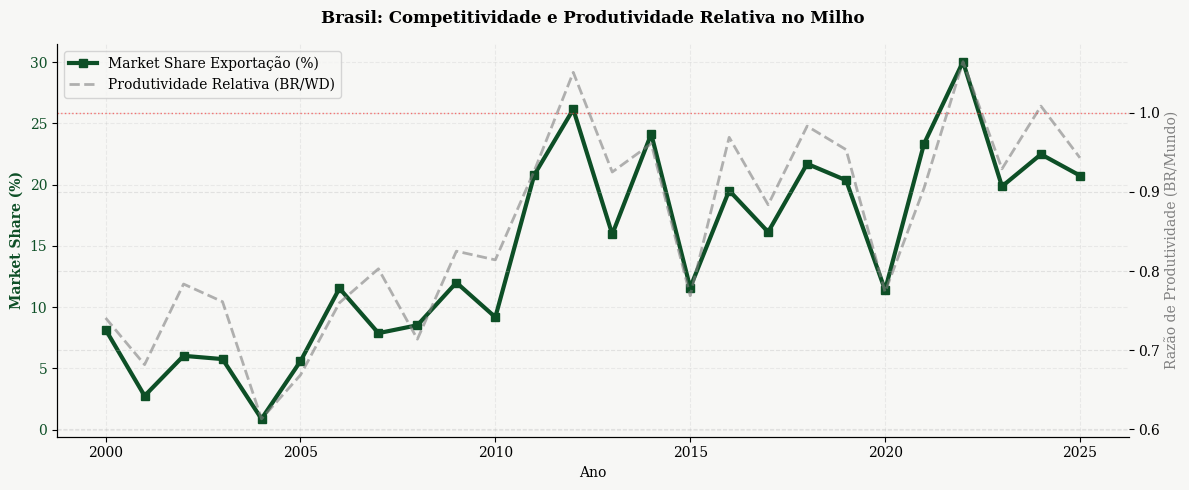

In [89]:
# ============================================================
# CÁLCULO DE MARKET SHARE E DRIVERS (VERSÃO CORRIGIDA)
# ============================================================

# 1. Criando o df_ms incluindo as colunas macro que estavam no df_br
df_ms = pd.merge(
    df_br[['Ano', 'Producao', 'Exportacao', 'Yield', 'Taxa_Cambio', 'Taxa_Selic', 'IC_Br_Agro', 'IPCA_Anual_Pct']],
    df_wd[['Ano', 'Producao', 'Exportacao', 'Yield']], 
    on='Ano', suffixes=('_BR', '_WD')
)

# 2. Cálculos de Share e Produtividade Relativa
df_ms['MS_Exportacao'] = (df_ms['Exportacao_BR'] / df_ms['Exportacao_WD']) * 100
df_ms['Yield_Relativo'] = df_ms['Yield_BR'] / df_ms['Yield_WD']


# ============================================================
# GRAFICO: MS Exportação vs Produtividade Relativa
# ============================================================
fig, ax1 = plt.subplots(figsize=(12, 5))

# Linha de Market Share
ax1.plot(df_ms['Ano'], df_ms['MS_Exportacao'], color=COR_EXPORT, lw=3, marker='s', label='Market Share Exportação (%)')
ax1.set_ylabel('Market Share (%)', color=COR_EXPORT, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=COR_EXPORT)

# Eixo Gêmeo para Produtividade Relativa
ax2 = ax1.twinx()
ax2.plot(df_ms['Ano'], df_ms['Yield_Relativo'], color='gray', lw=2, ls='--', alpha=0.6, label='Produtividade Relativa (BR/WD)')
ax2.axhline(1, color='red', lw=1, ls=':', alpha=0.5) 
ax2.set_ylabel('Razão de Produtividade (BR/Mundo)', color='gray')

ax1.set_title("Brasil: Competitividade e Produtividade Relativa no Milho", fontweight='bold', pad=15)
ax1.set_xlabel("Ano")
ax1.grid(alpha=0.2)

# Unificando as legendas
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

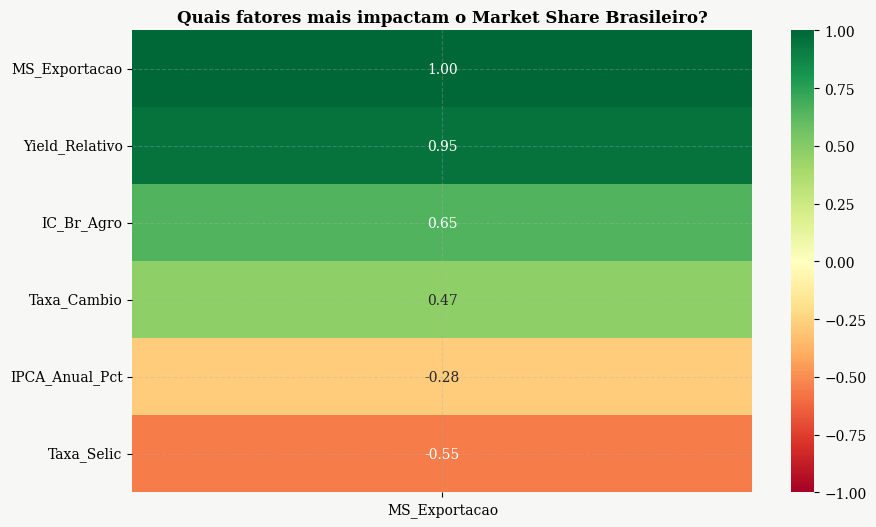

In [90]:
# ============================================================
# 1. HEATMAP DE DRIVERS (FOCO EM MARKET SHARE)
# ============================================================
# Selecionamos apenas o que importa para o Share
cols_drivers = ['MS_Exportacao', 'Yield_Relativo', 'Taxa_Cambio', 'Taxa_Selic', 'IC_Br_Agro', 'IPCA_Anual_Pct']
matriz_drivers = df_ms[cols_drivers].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(matriz_drivers[['MS_Exportacao']].sort_values(by='MS_Exportacao', ascending=False), 
            annot=True, cmap='RdYlGn', vmin=-1, vmax=1, fmt=".2f")

plt.title("Quais fatores mais impactam o Market Share Brasileiro?", fontweight='bold')
plt.show()



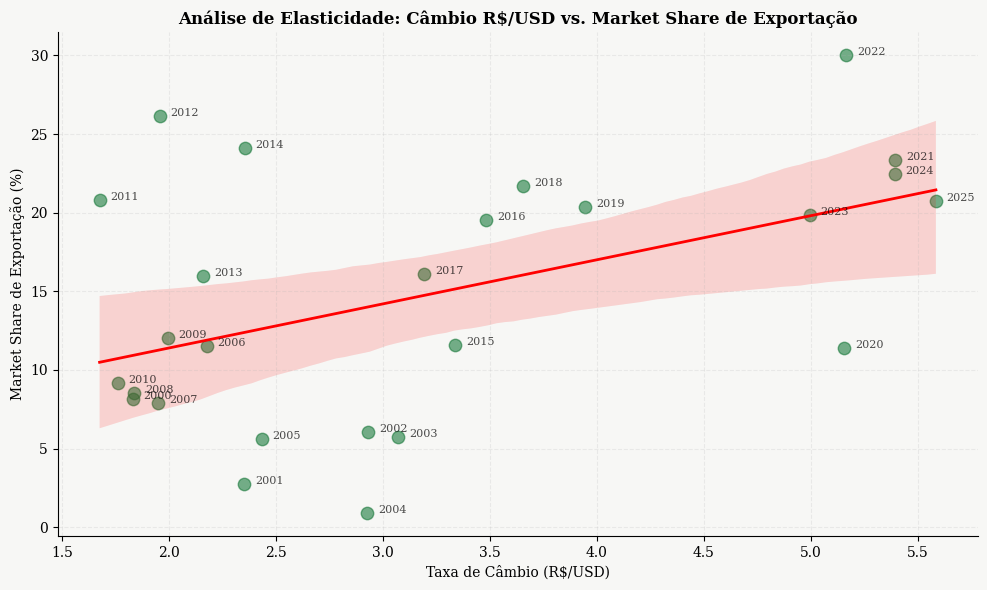

In [91]:
# ============================================================
# 2. SCATTER PLOT: CÂMBIO VS MARKET SHARE (COM LINHA DE TENDÊNCIA)
# ============================================================
plt.figure(figsize=(10, 6))

# Plotando os pontos e a linha de regressão (tendência)
sns.regplot(data=df_ms, x='Taxa_Cambio', y='MS_Exportacao', 
            scatter_kws={'s':80, 'alpha':0.6, 'color':COR_BRASIL}, 
            line_kws={'color':'red', 'lw':2})

# Anotações para os anos (mostrando o caminho histórico)
for i in range(len(df_ms)):
    plt.text(df_ms['Taxa_Cambio'].iloc[i]+0.05, df_ms['MS_Exportacao'].iloc[i], 
             str(int(df_ms['Ano'].iloc[i])), fontsize=8, alpha=0.7)

plt.title("Análise de Elasticidade: Câmbio R$/USD vs. Market Share de Exportação", fontweight='bold')
plt.xlabel("Taxa de Câmbio (R$/USD)")
plt.ylabel("Market Share de Exportação (%)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()